In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
save_path="data_output/demand_utc12.csv"

demand = pd.read_csv("data_input/demand_by_zone.csv")

In [12]:
demand.head()

,Period start,Period end,Region ID,Region,Demand (GWh),Demand ($)
0,01/01/2014 00:00:00,01/01/2014 00:30:00,UNI,Upper North Island,0.449,22954.15
1,01/01/2014 00:00:00,01/01/2014 00:30:00,CNI,Central North Island,0.368,18214.13
2,01/01/2014 00:00:00,01/01/2014 00:30:00,LNI,Lower North Island,0.216,10266.78
3,01/01/2014 00:00:00,01/01/2014 00:30:00,USI,Upper South Island,0.226,8243.61
4,01/01/2014 00:00:00,01/01/2014 00:30:00,LSI,Lower South Island,0.452,16194.13


In [13]:
demand = demand[['Period start', 'Region ID', 'Demand (GWh)']].rename(columns={
    'Period start': 'datetime',
    'Region ID': 'region_id',
    'Demand (GWh)': 'demand_GWh'
})

In [14]:
demand['datetime'] = pd.to_datetime(demand['datetime'], dayfirst=True)

In [15]:
demand = demand.pivot(index='datetime', columns='region_id', values='demand_GWh')
demand.columns = [f'demand_GWh_{col}' for col in demand.columns]

In [16]:
demand.head()

,demand_GWh_CNI,demand_GWh_LNI,demand_GWh_LSI,demand_GWh_UNI,demand_GWh_USI
datetime,,,,,
2014-01-01 00:00:00,0.368,0.216,0.452,0.449,0.226
2014-01-01 00:30:00,0.358,0.208,0.447,0.440,0.220
2014-01-01 01:00:00,0.348,0.194,0.441,0.428,0.206
2014-01-01 01:30:00,0.341,0.188,0.437,0.415,0.193
2014-01-01 02:00:00,0.332,0.186,0.433,0.403,0.182


In [17]:
# see all sub-30min rows across all years
print(demand[demand.index.minute.isin([40, 50])].index.tolist())

[Timestamp('2014-04-06 02:40:00'), Timestamp('2014-04-06 02:50:00'), Timestamp('2015-04-05 02:40:00'), Timestamp('2015-04-05 02:50:00'), Timestamp('2016-04-03 02:40:00'), Timestamp('2016-04-03 02:50:00'), Timestamp('2017-04-02 02:40:00'), Timestamp('2017-04-02 02:50:00'), Timestamp('2019-04-07 02:40:00'), Timestamp('2019-04-07 02:50:00'), Timestamp('2020-04-05 02:40:00'), Timestamp('2020-04-05 02:50:00'), Timestamp('2021-04-04 02:40:00'), Timestamp('2021-04-04 02:50:00'), Timestamp('2022-04-03 02:40:00'), Timestamp('2022-04-03 02:50:00'), Timestamp('2023-04-02 02:40:00'), Timestamp('2023-04-02 02:50:00'), Timestamp('2024-04-07 02:40:00'), Timestamp('2024-04-07 02:50:00'), Timestamp('2025-04-06 02:40:00'), Timestamp('2025-04-06 02:50:00'), Timestamp('2026-04-05 02:40:00'), Timestamp('2026-04-05 02:50:00')]


In [18]:
# Step 1: extract the sub-30min rows FROM ORIGINAL
extra_hour_data = demand[demand.index.minute.isin([40, 50])].copy()

# Step 2: drop them from original before we work on it
demand_clean = demand[~demand.index.minute.isin([40, 50])].copy()

# Step 3: convert clean original to fixed UTC+12
demand_utc12 = demand_clean.copy()
demand_utc12.index = (
    pd.to_datetime(demand_utc12.index)
    .tz_localize('Pacific/Auckland', ambiguous='NaT', nonexistent='NaT')
    .tz_convert('Etc/GMT-12')
    .tz_localize(None)
)

# Step 4: drop NaT rows
demand_utc12 = demand_utc12[demand_utc12.index.notna()]

# Step 5: remap 02:40 → 02:00, 02:50 → 02:30
extra_hour_data.index = extra_hour_data.index.map(
    lambda ts: ts.replace(minute=0 if ts.minute == 40 else 30)
)

# Step 6: reinsert and sort
demand_utc12 = pd.concat([demand_utc12, extra_hour_data]).sort_index()

# Step 7: verify
print(demand_utc12[demand_utc12.index.duplicated(keep=False)])

Empty DataFrame
Columns: [demand_GWh_CNI, demand_GWh_LNI, demand_GWh_LSI, demand_GWh_UNI, demand_GWh_USI]
Index: []


In [19]:
# see all sub-30min rows across all years
print(demand_utc12[demand_utc12.index.minute.isin([40, 50])].index.tolist())

[]


AttributeError: 'Axes' object has no attribute 'xa'

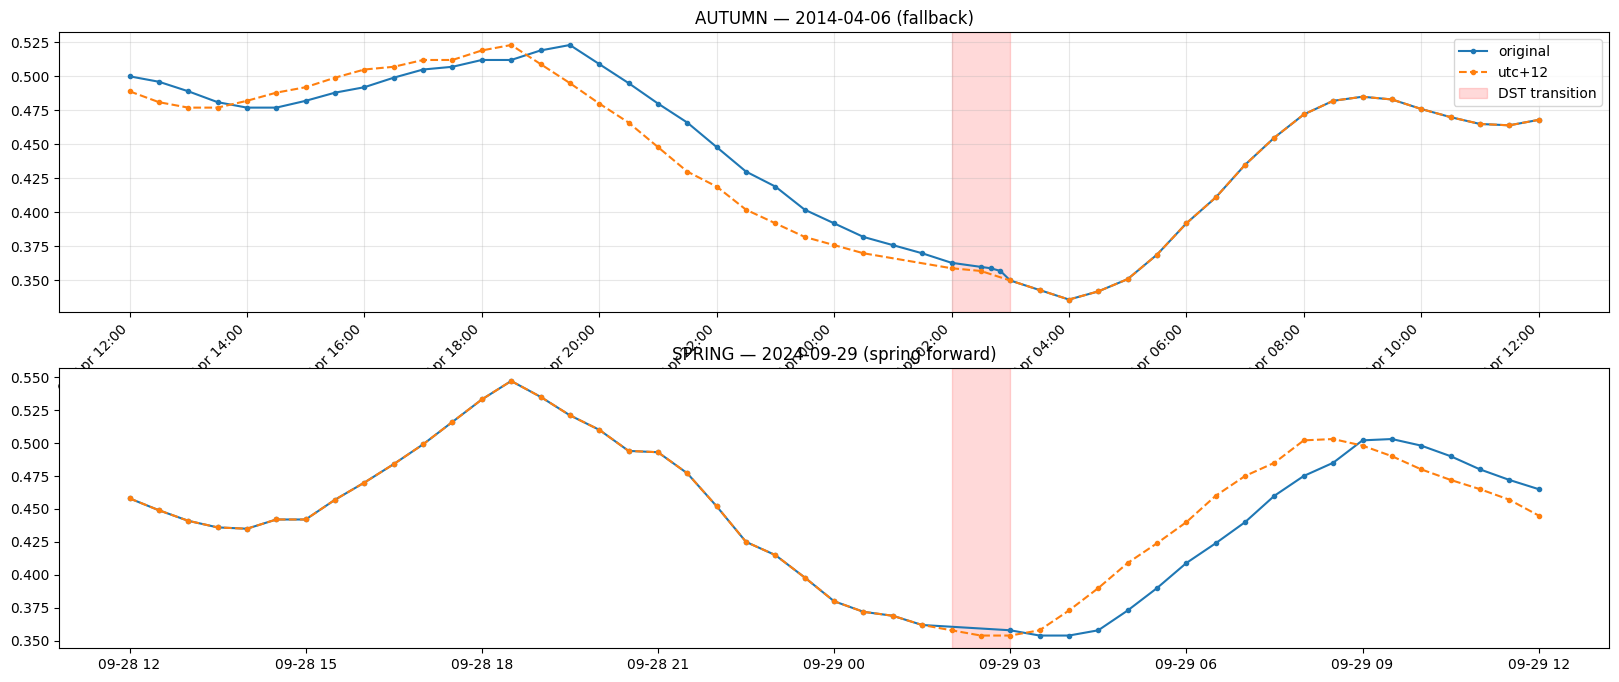

In [21]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

col = 'demand_GWh_CNI'

# --- SET DATES HERE ---
autumn_date = '2014-04-06'
spring_date = '2024-09-29'

# --- AUTUMN ---
aut_start = pd.Timestamp(autumn_date) - pd.Timedelta(hours=12)
aut_end   = pd.Timestamp(autumn_date) + pd.Timedelta(hours=12)
aut_orig  = demand[aut_start:aut_end][col]
aut_utc   = demand_utc12[aut_start:aut_end][col]

# --- SPRING ---
spr_start = pd.Timestamp(spring_date) - pd.Timedelta(hours=12)
spr_end   = pd.Timestamp(spring_date) + pd.Timedelta(hours=12)
spr_orig  = demand[spr_start:spr_end][col]
spr_utc   = demand_utc12[spr_start:spr_end][col]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 8))

# Autumn
ax1.plot(aut_orig.index, aut_orig.values, label='original', marker='o', markersize=3)
ax1.plot(aut_utc.index,  aut_utc.values,  label='utc+12',   marker='o', markersize=3, linestyle='--')
ax1.axvspan(pd.Timestamp(autumn_date).replace(hour=2), pd.Timestamp(autumn_date).replace(hour=3), alpha=0.15, color='red', label='DST transition')
ax1.set_title(f'AUTUMN — {autumn_date} (fallback)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b %H:%M'))
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Spring
ax2.plot(spr_orig.index, spr_orig.values, label='original', marker='o', markersize=3)
ax2.plot(spr_utc.index,  spr_utc.values,  label='utc+12',   marker='o', markersize=3, linestyle='--')
ax2.axvspan(pd.Timestamp(spring_date).replace(hour=2), pd.Timestamp(spring_date).replace(hour=3), alpha=0.15, color='red', label='DST transition')
ax2.set_title(f'SPRING — {spring_date} (spring forward)')
ax2.xa

In [22]:
demand_utc12.reset_index(inplace=True)
demand_utc12.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217390 entries, 0 to 217389
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   datetime        217390 non-null  datetime64[ns]
 1   demand_GWh_CNI  217320 non-null  float64       
 2   demand_GWh_LNI  217311 non-null  float64       
 3   demand_GWh_LSI  217289 non-null  float64       
 4   demand_GWh_UNI  217303 non-null  float64       
 5   demand_GWh_USI  217297 non-null  float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 10.0 MB


In [23]:
demand_utc12.describe()

,datetime,demand_GWh_CNI,demand_GWh_LNI,demand_GWh_LSI,demand_GWh_UNI,demand_GWh_USI
count,217390,217320.000000,217311.000000,217289.000000,217303.000000,217297.000000
mean,2020-03-14 17:21:08.280049920,0.479747,0.319495,0.521567,0.673695,0.355197
min,2013-12-31 23:00:00,0.251000,0.163000,0.333000,0.328000,0.165000
25%,2017-02-06 07:37:30,0.410000,0.256000,0.490000,0.543000,0.304000
50%,2020-03-14 17:15:00,0.490000,0.324000,0.524000,0.687000,0.357000
75%,2023-04-21 02:52:30,0.539000,0.368000,0.552000,0.778000,0.404000
max,2026-05-27 12:30:00,0.752000,0.604000,0.668000,1.209000,0.569000
std,NaN,0.083919,0.076123,0.042158,0.146396,0.067849


In [24]:
demand_utc12.to_csv(save_path, index=False)
print(f"✅ demand has been cleaned and saved under {save_path} ✅")

✅ demand has been cleaned and saved under data_output/demand_utc12.csv ✅


In [25]:
demand_utc12.head(50)

,datetime,demand_GWh_CNI,demand_GWh_LNI,demand_GWh_LSI,demand_GWh_UNI,demand_GWh_USI
0,2013-12-31 23:00:00,0.368,0.216,0.452,0.449,0.226
1,2013-12-31 23:30:00,0.358,0.208,0.447,0.440,0.220
2,2014-01-01 00:00:00,0.348,0.194,0.441,0.428,0.206
3,2014-01-01 00:30:00,0.341,0.188,0.437,0.415,0.193
4,2014-01-01 01:00:00,0.332,0.186,0.433,0.403,0.182
5,2014-01-01 01:30:00,0.322,0.182,0.430,0.392,0.176
6,2014-01-01 02:00:00,0.317,0.180,0.426,0.386,0.171
7,2014-01-01 02:30:00,0.315,0.178,0.426,0.382,0.169
8,2014-01-01 03:00:00,0.314,0.178,0.427,0.380,0.169
9,2014-01-01 03:30:00,0.313,0.178,0.429,0.380,0.173
